In [4]:
import warnings
from math import sqrt
from os.path import exists
# Initialize Wandb
import wandb
print(wandb.__version__)
import matplotlib.pyplot as plt
from matplotlib import pyplot
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback
from wandb.integration.keras import WandbMetricsLogger
from numpy import concatenate
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.dates as mdates
from keras.callbacks import EarlyStopping
from keras.layers import Bidirectional, Dense, Dropout, LSTM, BatchNormalization
from keras.models import Sequential
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.layers import Concatenate, Dense, Embedding, Input, LSTM
import os, random, tensorflow as tf

os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#path to the dataset
ori_data = pd.read_csv("/home/stelios-pc/Desktop/PhD/Paper/tSDG-DiffusionTS-DataAugmentation/Pipeline/Individual Household Electric Power Consumption Dataset/household_power_consumption.txt", sep=';')
ori_data['Timestamp'] = pd.to_datetime(ori_data['Date'] + ' ' + ori_data['Time'], format='%d/%m/%Y %H:%M:%S')

ori_data['Timestamp'] = pd.to_datetime(ori_data["Timestamp"])
ori_data.drop(columns=['Date', 'Time'], inplace=True)
# Identify object columns that should be numeric
object_cols = ori_data.select_dtypes(include='object').columns
print("Object columns:", object_cols)

# Convert each to numeric, coercing errors (e.g., '?' → NaN)
for col in object_cols:
    ori_data[col] = pd.to_numeric(ori_data[col], errors='coerce')

ori_data.set_index('Timestamp', inplace=True)
cols_to_interp = ['Global_active_power',
                  'Global_reactive_power',
                  'Voltage',
                  'Global_intensity']
ori_data[cols_to_interp] = ori_data[cols_to_interp].interpolate(
    method='time', limit=60, limit_direction='both'
)

sub_cols = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
ori_data[sub_cols] = ori_data[sub_cols].interpolate(method='time', limit=2, limit_direction='both')

per_window_counts = ori_data[sub_cols].notna().resample('1h').sum()
ok_windows = (per_window_counts >= 0.95 * 60).all(axis=1)


0.18.5


/tmp/ipykernel_454465/3914913661.py:37: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  ori_data = pd.read_csv("/home/stelios-pc/Desktop/PhD/Paper/tSDG-DiffusionTS-DataAugmentation/Pipeline/Individual Household Electric Power Consumption Dataset/household_power_consumption.txt", sep=';')


Object columns: Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2'],
      dtype='object')


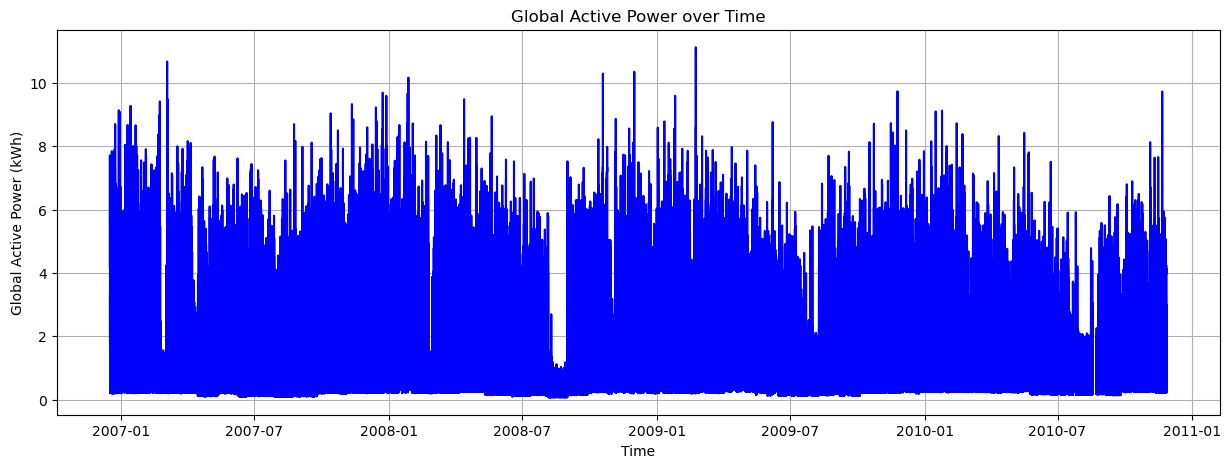

In [5]:
# code to plot the 'Global_active_energy' column
plt.figure(figsize=(15, 5))
plt.plot(ori_data['Global_active_power'], color='blue')
plt.title('Global Active Power over Time')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kWh)')
plt.grid(True)
plt.show()

In [6]:
df_daily = pd.DataFrame({
    'Global_active_energy_kWh': ori_data['Global_active_power'].resample('1h').sum() * (1/60),
    'Global_reactive_power'   : ori_data['Global_reactive_power'].resample('1h').mean(),
    'Voltage'                 : ori_data['Voltage'].resample('1h').mean(),
    'Global_intensity'        : ori_data['Global_intensity'].resample('1h').mean(),
})

df_daily[['Sub_metering_1','Sub_metering_2','Sub_metering_3']] = (
    ori_data[sub_cols].resample('1h').sum() / 1000.0  # Wh → kWh
)

In [7]:
bad_windows = ~ok_windows.reindex(df_daily.index).fillna(True)

# Linear interpolation across days for missing/zeroed totals
cols_to_interp_daily = ['Global_active_energy_kWh','Global_reactive_power',
                        'Voltage','Global_intensity',
                        'Sub_metering_1','Sub_metering_2','Sub_metering_3']

df_daily.loc[bad_windows, cols_to_interp_daily] = pd.NA
df_daily[cols_to_interp_daily] = df_daily[cols_to_interp_daily].interpolate(
    method='linear', limit_direction='both'
)

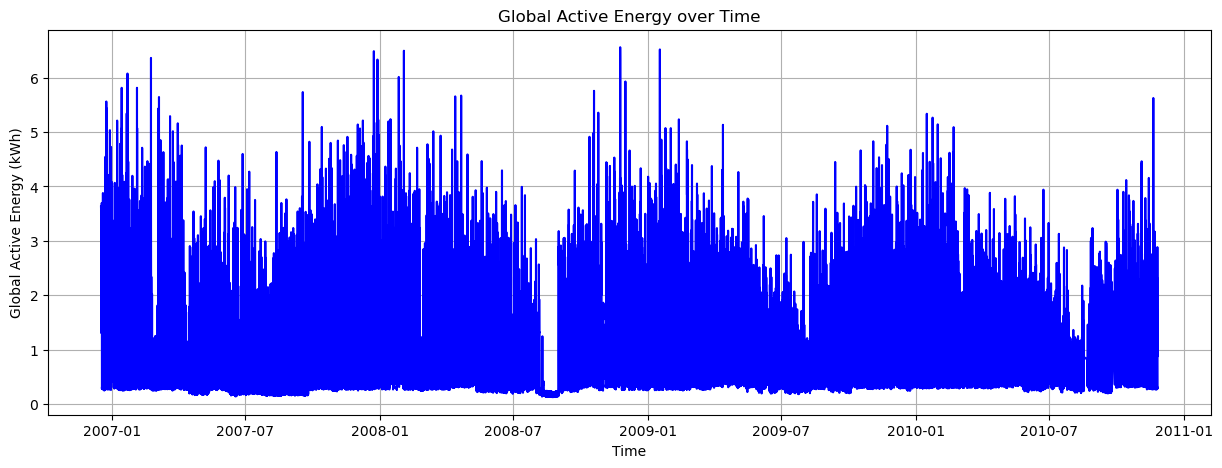

In [8]:
# code to plot the 'Global_active_energy' column
plt.figure(figsize=(15, 5))
plt.plot(df_daily['Global_active_energy_kWh'], color='blue')
plt.title('Global Active Energy over Time')
plt.xlabel('Time')
plt.ylabel('Global Active Energy (kWh)')
plt.grid(True)
plt.show()

df_daily.reset_index(inplace=True)

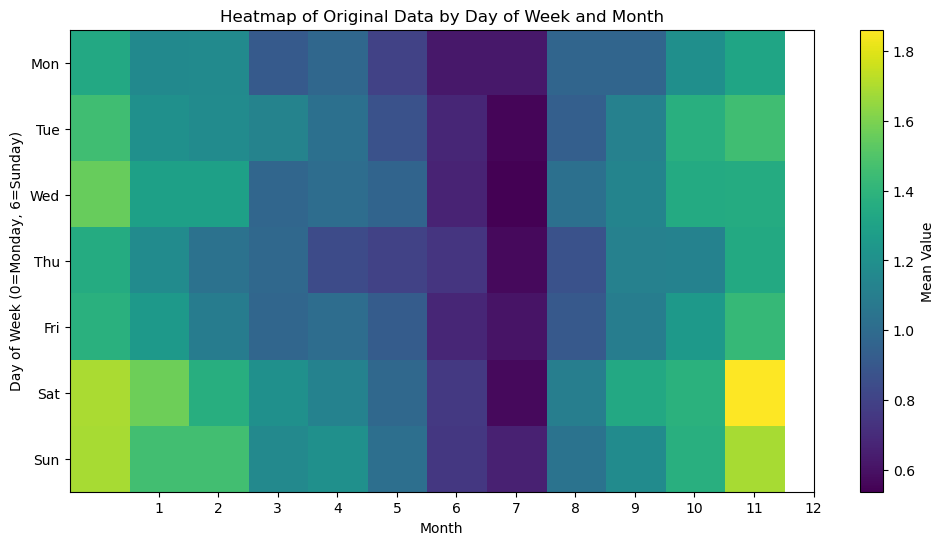

In [9]:
# Plot the heat map of original data based on day of week and month and delete the newly added columns

def plot_heatmap(data):
    """
    Plot a heatmap of the original data based on day of week and hour.
    
    Args:
        data (pd.DataFrame): DataFrame containing the original data with 'Timestamp' column.
    """
    # Extract day of week and hour from the timestamp
    data['day_of_week'] = data['Timestamp'].dt.dayofweek
    data['month'] = data['Timestamp'].dt.month
    
    # Create a pivot table for the heatmap
    heatmap_data = data.pivot_table(index='day_of_week', columns='month', values='Global_active_energy_kWh', aggfunc='mean')
    
    # Plot the heatmap
    plt.figure(figsize=(12, 6))
    plt.title('Heatmap of Original Data by Day of Week and Month')
    plt.imshow(heatmap_data, cmap='viridis', aspect='auto')
    plt.colorbar(label='Mean Value')
    plt.xlabel('Month')
    plt.ylabel('Day of Week (0=Monday, 6=Sunday)')
    plt.xticks(ticks=np.arange(1, 13), labels=np.arange(1, 13))
    plt.yticks(ticks=np.arange(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    plt.show()
    
    # Drop the newly added columns
    data.drop(columns=['day_of_week', 'month'], inplace=True)

plot_heatmap(df_daily)

<Figure size 640x480 with 0 Axes>

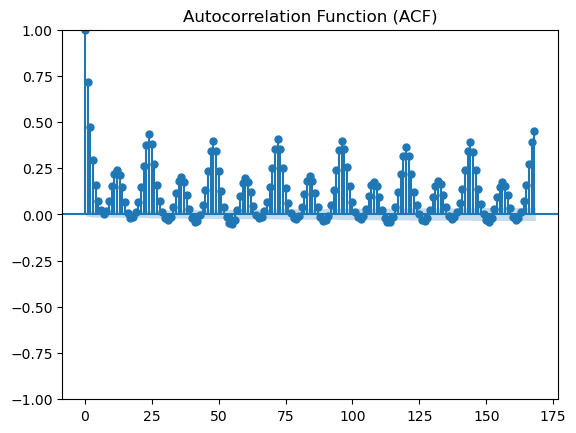

<Figure size 640x480 with 0 Axes>

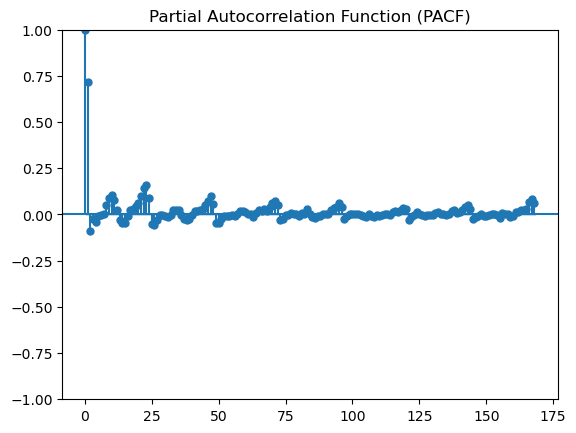

In [10]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


series = df_daily['Global_active_energy_kWh']

# 1) Autocorrelation Function
plt.figure()
plot_acf(series, lags=24*7)        # adjust lags as needed
plt.title('Autocorrelation Function (ACF)')
plt.show()

# 2) Partial Autocorrelation Function
plt.figure()
plot_pacf(series, lags=24*7, method='ywm')  # you can also try method='ld' or 'ywmle'
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()


In [11]:
def standard_scaler(data):

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    return scaled_data, scaler

def min_max_scaler(data):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    return scaled_data, scaler

In [12]:
def XGBoost_model(X_train, Y_train, X_val, Y_val, X_test, Y_test, seed_val=42, pinball_loss_usage=False, n_past=10):
    """
    Trains XGBoost quantile regression models for 5%, 50%, 95% intervals.
    """

    quantiles = [0.05, 0.5, 0.95]
    models = {}
    predictions = {}
    X_test = X_test[n_past:-1]
    Y_test = Y_test[n_past:-1]
    if pinball_loss_usage:
        for q in quantiles:
            train_data = xgb.QuantileDMatrix(X_train, label=Y_train)
            val_data = xgb.QuantileDMatrix(X_val, label=Y_val)
            test_data = xgb.QuantileDMatrix(X_test, label=Y_test)

            params = {
                'objective': 'reg:quantileerror',
                'quantile_alpha': q,
                'eval_metric': 'mae',
                'learning_rate': 0.01,
                'max_depth': 5,
                'gamma': 1.0,
                'alpha': 0.1,
                'colsample_bytree': 0.8,
                'colsample_bynode': 0.8,
                'lambda': 0.1,
                'tree_method': 'hist',  # Required for QuantileDMatrix
                'seed': seed_val,
            }

            evals = [(train_data, 'train'), (val_data, 'eval')]
            model = xgb.train(params, train_data, num_boost_round=2000, early_stopping_rounds=100, evals=evals, verbose_eval=False)

            models[q] = model
            predictions[q] = model.predict(test_data)
        print("Shape of Y_test: ", Y_test.shape)
        return {
            'models': models,
            'predictions': predictions,
            'y_true': Y_test
        }
    else:
        train_data = xgb.DMatrix(X_train, label=Y_train)
        val_data = xgb.DMatrix(X_val, label=Y_val)
        test_data = xgb.DMatrix(X_test, label=Y_test)

        params = {
                'objective': 'reg:squarederror',
                # 'quantile_alpha': q,
                'eval_metric': 'rmse',
                'learning_rate': 0.01,
                'max_depth': 5,
                'gamma': 1.0,
                'alpha': 0.1,
                'colsample_bytree': 0.8,
                'colsample_bynode': 0.8,
                'lambda': 0.1,
                'tree_method': 'hist',  # Required for QuantileDMatrix
                'seed': seed_val,
            }

        evals = [(train_data, 'train'), (val_data, 'eval')]
        model = xgb.train(params, train_data, num_boost_round=1000, early_stopping_rounds=100, evals=evals, verbose_eval=False)
        predictions = model.predict(test_data)
        return predictions, model
def RF_model(X_train, Y_train, seed_val=42):
    from sklearn.ensemble import RandomForestRegressor
    
    model = RandomForestRegressor(n_estimators=100, random_state=seed_val)
    model.fit(X_train, Y_train)
    return model

def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q * e, (q - 1) * e))
    return loss

def BiLSTM_model(X_train, q, pinball_loss_usage=False):
        """Normalize all features to zero mean and unit variance (StandardScaler) after cutting your windows.


        Constructing the Bidirectional LSTM architecture.

        Returns:
            model (keras.model) : Returns the keras model.
        """
        # lr_schedule = ExponentialDecay(0.001, decay_steps=2500, decay_rate=0.96, staircase=True)
        model = Sequential()
        # model.add(Bidirectional(LSTM(50, activation='tanh', return_sequences=True, dropout= 0.1, recurrent_dropout= 0.2, input_shape=(X_train.shape[1], X_train.shape[2])), merge_mode='concat'))
        model.add(Bidirectional(LSTM(128, activation='tanh', return_sequences=True, dropout= 0.1, recurrent_dropout=0.2,input_shape=(X_train.shape[1], X_train.shape[2]))))
        # model.add(BatchNormalization())
        model.add(Dropout(0.1))
        model.add(Bidirectional(LSTM(128, activation='tanh', dropout= 0.1, recurrent_dropout=0.2, return_sequences=False)))
        # model.add(BatchNormalization())
        model.add(Dropout(0.1))
        model.add(Dense(1, activation='linear'))
        optimizer = Adam(learning_rate= 0.004)
        if pinball_loss_usage:
            model.compile(loss=quantile_loss(q), optimizer=optimizer, metrics=['mae', 'mape', 'mse'])
        else:
            model.compile(loss='mse', optimizer=optimizer, metrics=['mae', 'mape'])
        return model


def LSTM_model(X_train, q, pinball_loss_usage=False):
    # lr_schedule = ExponentialDecay(0.001, decay_steps=2500, decay_rate=0.96, staircase=True)
    model = Sequential()
    model.add(LSTM(128, activation= 'tanh', return_sequences=True, dropout= 0.1, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2])))
    # model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(LSTM(64, activation= 'tanh', recurrent_dropout=0.2, dropout= 0.1, return_sequences=False))
    # model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))
    # optimizer = Adam(learning_rate=lr_schedule)
    if pinball_loss_usage:
        model.compile(loss=quantile_loss(q), optimizer='Adam', metrics=['mae', 'mape', 'mse'])
    else:
        model.compile(loss='mse', optimizer='Adam', metrics=['mae', 'mape'])

    return model

/home/stelio/miniconda3/envs/tensorflow_gpu/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/stelio/miniconda3/envs/tensorflow_gpu/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Mean Absolute Error (MAE): 0.7447192152668611
Mean squared error (MSE): 0.9623569283620852
Root Mean Squared Error (RMSE): 0.9809979247491226
R² Score: -0.7279767221026952
SMAPE score: 103.50180427178348


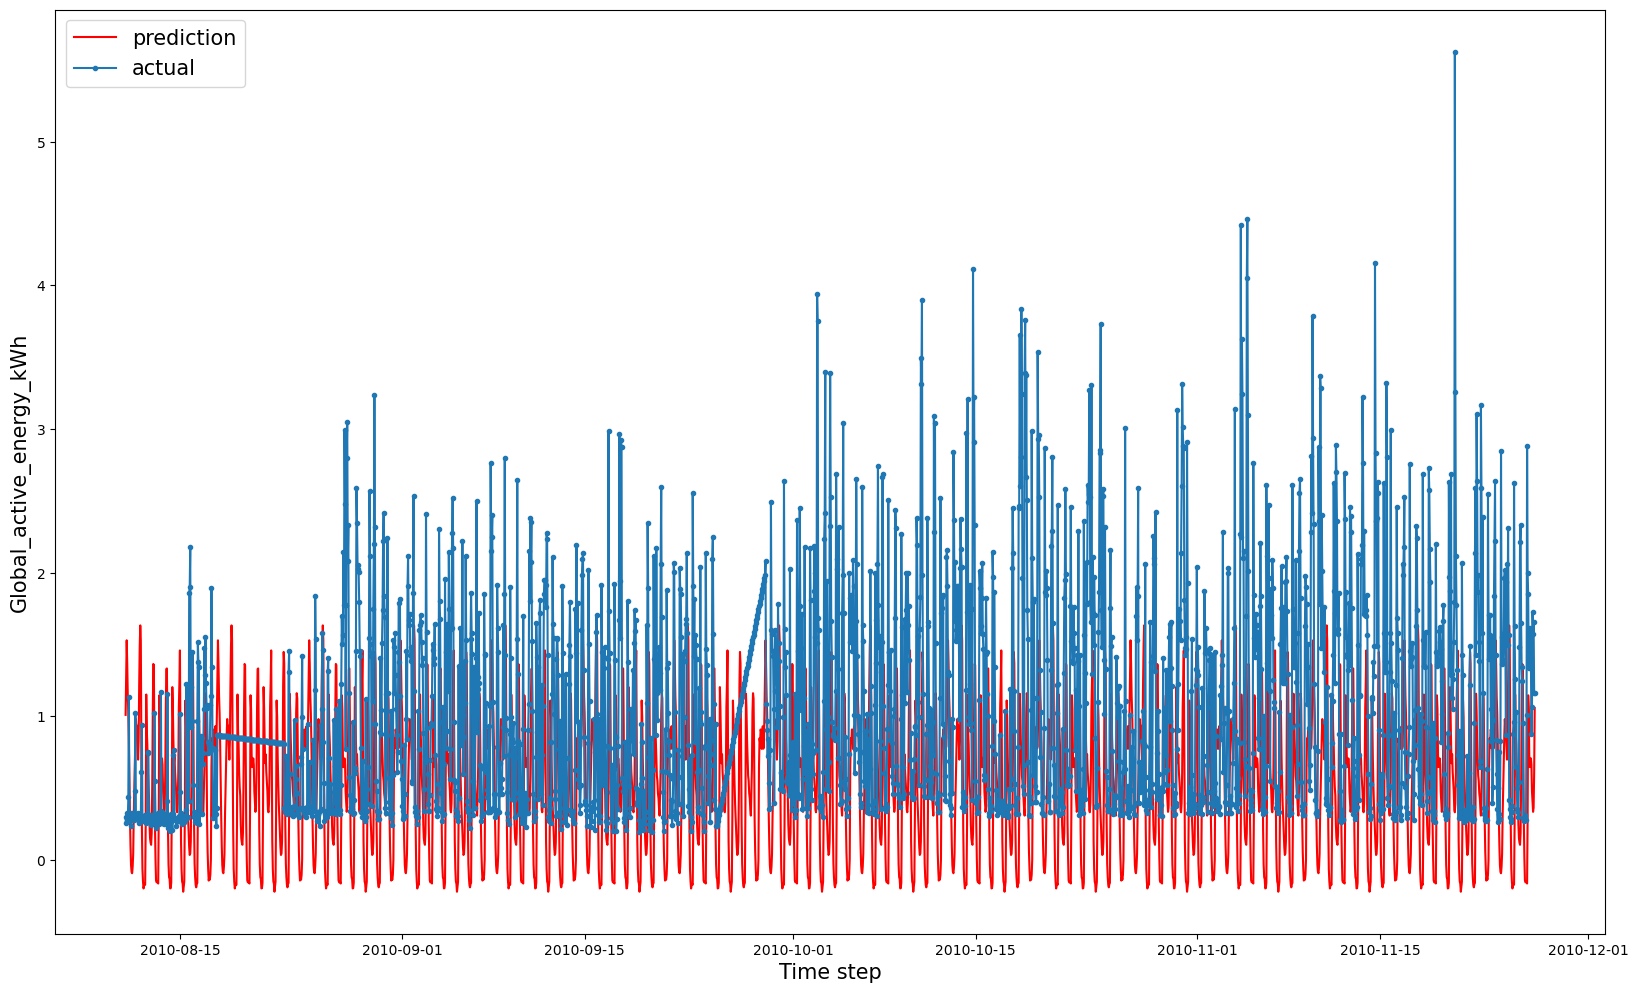

In [10]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# Baseline model
def Exp_Smoothing_model(train):
    """
    Constructing the Exponential Smoothing model.

    Returns:
        model (statsmodels.tsa.holtwinters.ExponentialSmoothing) : Returns the fitted model.
    """
    # Fit the model
    model = ExponentialSmoothing(train, trend='add', seasonal='add', damped_trend=True, seasonal_periods=24*7).fit()
    return model



# Baseline model
data = df_daily[['Timestamp','Global_active_energy_kWh']].copy()
# Ensure 'Timestamp' is the index
data.set_index('Timestamp', inplace=True)

series = data['Global_active_energy_kWh']
n = len(series)
train_end = int(n * 0.85)
val_end = train_end + int(n * 0.075)
train = series[:train_end]
val   = series[train_end:val_end]
test  = series[val_end:]
model = Exp_Smoothing_model(train)

forecast_steps = len(test)
forecast = model.forecast(forecast_steps)
forecast.index = test.index

shape2 = len(test)
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)
n = len(test)
p = shape2
# MASE function
def mase(y_true, y_pred, y_naive):
    # y_true: Actual values
    # y_pred: Predicted values
    # y_naive: Naive model predictions (e.g., previous period's values)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_naive = np.asarray(y_naive)
    # Compute errors
    errors = np.abs(y_true - y_pred)
    
    # Calculate MAE of naive model
    naive_errors = np.abs(y_true[1:] - y_naive[1:])
    mae_naive = np.mean(naive_errors)
    
    # Calculate MASE
    mase_value = np.mean(errors) / mae_naive
    return mase_value
# SMAPE function
def smape(y_true, y_pred):
    # y_true: Actual values
    # y_pred: Predicted values
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    # Calculate SMAPE
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    smape_value = 100 * np.mean(diff)
    return smape_value

smape_val = smape(test, forecast)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean squared error (MSE): {mean_squared_error(test, forecast)}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R² Score: {r2}')
print(f"SMAPE score: {smape_val}")



plt.figure(figsize=(20,12))
plt.plot(forecast, label='prediction', color="r")
plt.plot(test, label='actual', marker='.')
plt.legend()
plt.ylabel('Global_active_energy_kWh', size=15)
plt.xlabel('Time step', size=15)
plt.legend(fontsize=15)
plt.show()

In [11]:
df_daily.columns

Index(['Timestamp', 'Global_active_energy_kWh', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [ ]:
def training(seed_val = 42, model_type = 'BiLSTM', n_past = 24*7, batch_size = 32, scaler_name = 'min-max', data_augmentation = False, fake_data_length = 400, testing_stage = False, pinball_loss_usage = False):
    # Define seed for reproducibility
    os.environ["PYTHONHASHSEED"] = str(seed_val)
    random.seed(seed_val)
    np.random.seed(seed_val)
    tf.random.set_seed(seed_val)

    data = df_daily.copy()
    n_past = n_past # the ACF shows around 50 lags
    n_future = 1

    data['Timestamp'] = pd.to_datetime(data['Timestamp'])

    # Window sliding technique used for Deep Learning models
    def split_sequence(X, Y, steps, out):
        Xs, Ys = list(), list()
        for i in range(len(X)):
            end = i + steps
            outi = end + out
            if outi > len(X)-1:
                break
            seqx, seqy = X[i:end], Y[end:outi]
            Xs.append(seqx)
            Ys.append(seqy)
        return np.array(Xs), np.array(Ys)
    
    # Add time features
    time_related_features = data[['Timestamp']].copy()  
    h = time_related_features['Timestamp'].dt.hour
    time_related_features['hour_sin'] = np.sin(2*np.pi * h / 24)
    time_related_features['hour_cos'] = np.cos(2*np.pi * h / 24)    
    time_related_features['month_sin'] = np.sin(2 * np.pi * time_related_features['Timestamp'].dt.month / 12)
    time_related_features['month_cos'] = np.cos(2 * np.pi * time_related_features['Timestamp'].dt.month / 12)
    time_related_features['day_of_week_sin'] = np.sin(2 * np.pi * time_related_features['Timestamp'].dt.dayofweek / 7)
    time_related_features['day_of_week_cos'] = np.cos(2 * np.pi * time_related_features['Timestamp'].dt.dayofweek / 7)

    # # Categorical features
    # data.set_index('Timestamp', inplace=True)
    # data['dow'] = data.index.day_name().str[:3]     # e.g. "Mon","Tue",…,"Sun"
    # data['hour'] = data.index.hour # 0–23
    # sun_low = data['dow'] == 'Sun' # basically all day on sunday
    # mon_low = (data['dow'] == 'Mon') & data['hour'].isin([0,1,2,3,4,5,6,7,8,9]) # basically from 0 to 9 on monday
    # wed_low = (data['dow'] == 'Wed') & data['hour'].isin([6,7,8,9,10,11,12,13,14]) # basically from 6 to 14 for maintenance on wednesday
    # sat_low = (data['dow'] == 'Sat') & data['hour'].isin([19,20,21,22,23]) # basically from 19 to 23 on saturday
    # data['is_low_usage'] = sun_low | mon_low | wed_low | sat_low
    # data.drop(columns=['dow', 'hour'], inplace=True)
    # data.reset_index(inplace=True)
    # data['is_low_usage'] = data['is_low_usage'].astype(int)
    # data['is_low_usage_next'] = data['is_low_usage'].shift(-1)
    
    X, Y, X_time= data.drop(columns=['Timestamp']), data['Global_active_energy_kWh'].values, time_related_features.drop(columns=['Timestamp'])
    X = pd.concat([X, X_time], axis=1)
    timestamps = data['Timestamp']
    X_train, X_val, Y_train, Y_val = train_test_split(X.values, Y, test_size=0.20, random_state=seed_val, shuffle=False)
    X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)
    # Split validation data 5% and 5% in order to test in the start and then use the other 5% for the second phase after selection
    X_val1, X_val2, Y_val1, Y_val2 = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)

    # Create aligned timestamp splits
    timestamps_train, timestamps_val, _Y_train_dummy, _Y_val_dummy = train_test_split(
        timestamps, Y, test_size=0.20, random_state=seed_val, shuffle=False
    )
    timestamps_val, timestamps_test, _Y_val_dummy, _Y_test_dummy = train_test_split(
        timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
    )
    timestamps_val1, timestamps_val2, _Y_val1_dummy, _Y_val2_dummy = train_test_split(
        timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
    )
    
    # print(X_train.shape, type(X_train), X_val1.shape, type(X_val1))
    X_train, Y_train = split_sequence(X_train, Y_train, n_past, n_future)
    # X_val1, Y_val1 = split_sequence(X_val1, Y_val1, n_past, n_future)
    X_test, Y_test = split_sequence(X_test, Y_test, n_past, n_future)
    X_val1, Y_val1 = split_sequence(X_val1, Y_val1, n_past, n_future)
    X_val2, Y_val2 = split_sequence(X_val2, Y_val2, n_past, n_future)

  
    # train-test split
    # X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=seed_val, shuffle=False)
    # X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.75, random_state=seed_val, shuffle=False)

    #-----------Now the data is Train: 80%, Val_1: 5%, Val_2: 5%, Test: 10%----------------#

    if testing_stage:
        X_train = np.concatenate([X_train, X_val1], axis=0) # concatenate validation set to training set
        Y_train = np.concatenate([Y_train, Y_val1], axis=0)
        timestamps = timestamps_test  # concatenate timestamps for training set
        X_val = X_val2  # use the second validation set for validation
        Y_val = Y_val2  # use the second validation set for validation
    else:
        X_val = X_val1
        Y_val = Y_val1
        timestamps = timestamps_val1

    n_feat = X_train.shape[2]
    # separate the lagged values, numerical and time features, time features are the last 4 features in the X, lagged value features is the last before the time features
    X_numerical_train = X_train[:, :, 1: n_feat - 6]    # (numerical features)
    X_lagged_train    = X_train[:, :, [0]]  # (lagged feature)
    X_time_train      = X_train[:, :, -6:]    # last 4 are time features (time-related features)

    # VAL
    X_numerical_val = X_val[:, :, 1: n_feat - 6]
    X_lagged_val    = X_val[:, :, [0]]
    X_time_val      = X_val[:, :, -6:]

    # TEST
    X_numerical_test = X_test[:, :, 1: n_feat - 6]
    X_lagged_test    = X_test[:, :, [0]]
    X_time_test      = X_test[:, :, -6:]

    if data_augmentation:
        fake_data = np.load("ddpm_fake_energy_raw.npy")
        fake_data = fake_data[:fake_data_length]
        _, seq_len, F = fake_data.shape
        X_fake = fake_data[:, :seq_len-1, :]
        Y_fake = fake_data[:, seq_len-1, F-1]
        Y_fake = Y_fake.reshape(-1, 1)
        X_fake_numerical_train = X_fake[:, :, :-7] 
        X_fake_cat_train= X_fake[:, :, -7:-5] 
        X_fake_lagged_train = X_fake[:, :, -1:] 
        X_fake_time_train = X_fake[:, :, -5:-1] 

    if scaler_name == 'min-max':

        N, seq_len, F = X_numerical_train.shape
        X_numerical_train, scaler = min_max_scaler(X_numerical_train.reshape(-1, X_numerical_train.shape[-1]))
        X_numerical_train = X_numerical_train.reshape(N, seq_len, F)
        X_numerical_val = scaler.transform(X_numerical_val.reshape(-1, X_numerical_val.shape[-1]))
        X_numerical_val = X_numerical_val.reshape(X_val.shape[0], seq_len, F)
        X_numerical_test = scaler.transform(X_numerical_test.reshape(-1, X_numerical_test.shape[-1]))
        X_numerical_test = X_numerical_test.reshape(X_test.shape[0], seq_len, F)
            
        Y_train, scaler_target = min_max_scaler(Y_train)
        Y_val = scaler_target.transform(Y_val)
        Y_test = scaler_target.transform(Y_test)
        X_lagged_train = scaler_target.transform(X_lagged_train.reshape(-1, X_lagged_train.shape[-1]))
        X_lagged_train = X_lagged_train.reshape(N, seq_len, 1)
        X_lagged_val = scaler_target.transform(X_lagged_val.reshape(-1, X_lagged_val.shape[-1]))
        X_lagged_val = X_lagged_val.reshape(X_val.shape[0], seq_len, 1)
        X_lagged_test = scaler_target.transform(X_lagged_test.reshape(-1, X_lagged_test.shape[-1]))
        X_lagged_test = X_lagged_test.reshape(X_test.shape[0], seq_len, 1)


        #fake data augmentation
        if data_augmentation:
            N, seq_len, F = X_fake_numerical_train.shape

            X_fake_numerical_train = scaler.transform(X_fake_numerical_train.reshape(-1, X_fake_numerical_train.shape[-1]))
            X_fake_numerical_train = X_fake_numerical_train.reshape(N, seq_len, F)
            X_fake_lagged_train = scaler_target.transform(X_fake_lagged_train.reshape(-1, X_fake_lagged_train.shape[-1]))
            X_fake_lagged_train = X_fake_lagged_train.reshape(N, seq_len, 1)
            Y_fake = scaler_target.transform(Y_fake)

    elif scaler_name == 'standard':

        N, seq_len, F = X_numerical_train.shape
        X_numerical_train, scaler = standard_scaler(X_numerical_train.reshape(-1, X_numerical_train.shape[-1]))
        X_numerical_train = X_numerical_train.reshape(N, seq_len, F)
        X_numerical_val = scaler.transform(X_numerical_val.reshape(-1, X_numerical_val.shape[-1]))
        X_numerical_val = X_numerical_val.reshape(X_val.shape[0], seq_len, F)
        X_numerical_test = scaler.transform(X_numerical_test.reshape(-1, X_numerical_test.shape[-1]))
        X_numerical_test = X_numerical_test.reshape(X_test.shape[0], seq_len, F)

        Y_train, scaler_target = standard_scaler(Y_train)
        Y_val = scaler_target.transform(Y_val)
        Y_test = scaler_target.transform(Y_test)
        X_lagged_train = scaler_target.transform(X_lagged_train.reshape(-1, X_lagged_train.shape[-1]))
        X_lagged_train = X_lagged_train.reshape(N, seq_len, 1)
        X_lagged_val = scaler_target.transform(X_lagged_val.reshape(-1, X_lagged_val.shape[-1]))
        X_lagged_val = X_lagged_val.reshape(X_val.shape[0], seq_len, 1)
        X_lagged_test = scaler_target.transform(X_lagged_test.reshape(-1, X_lagged_test.shape[-1]))
        X_lagged_test = X_lagged_test.reshape(X_test.shape[0], seq_len, 1)


        #fake data augmentation
        if data_augmentation:
            N, seq_len, F = X_fake_numerical_train.shape

            X_fake_numerical_train = scaler.transform(X_fake_numerical_train.reshape(-1, X_fake_numerical_train.shape[-1]))
            X_fake_numerical_train = X_fake_numerical_train.reshape(N, seq_len, F)
            X_fake_lagged_train = scaler_target.transform(X_fake_lagged_train.reshape(-1, X_fake_lagged_train.shape[-1]))
            X_fake_lagged_train = X_fake_lagged_train.reshape(N, seq_len, 1)
            Y_fake = scaler_target.transform(Y_fake)

    X_train = np.concatenate([X_numerical_train, X_time_train, X_lagged_train], axis=2)    
    X_val = np.concatenate([X_numerical_val, X_time_val, X_lagged_val], axis=2)
    X_test = np.concatenate([X_numerical_test, X_time_test, X_lagged_test], axis=2)
    # X_train = X_numerical_train
    # X_val = X_numerical_val
    # X_test = X_numerical_test

    if data_augmentation:
        X_fake = np.concatenate([X_fake_numerical_train, X_fake_cat_train, X_fake_time_train, X_fake_lagged_train], axis=2)
        X_train, Y_train = np.concatenate([X_train, X_fake], axis=0), np.concatenate([Y_train, Y_fake], axis=0)


    print("Size of training data is: ", X_train.shape)
    quantiles = [0.05, 0.5, 0.95]
    models = {}
    histories = {}

    early_stop = EarlyStopping(
                monitor='val_loss',     # or 'val_mae' depending on preference
                patience=15,             # stop after 15 epochs with no improvement
                restore_best_weights=True # rollback to the best model weights
    )
    if pinball_loss_usage:
        for q in quantiles:
            print(f"Training {model_type} for quantile {q}...")

            if model_type == 'BiLSTM':
                model = BiLSTM_model(X_train, q, pinball_loss_usage)
            elif model_type == 'LSTM':
                model = LSTM_model(X_train, q, pinball_loss_usage)

            history = model.fit(X_train, Y_train, validation_data = (X_val, Y_val), epochs=500, batch_size=batch_size, verbose=1, shuffle=True, callbacks=[early_stop, WandbMetricsLogger()])
            models[q] = model
            histories[q] = history
    else:
        print(f"Training {model_type}...")

        if model_type == 'BiLSTM':
            model = BiLSTM_model(X_train, 0, pinball_loss_usage)
        elif model_type == 'LSTM':
            model = LSTM_model(X_train, 0, pinball_loss_usage)
        
        model.fit(X_train, Y_train, validation_data = (X_val, Y_val), epochs=500, batch_size=batch_size, verbose=1, shuffle=True, callbacks=[early_stop, WandbMetricsLogger()])
        
    # print(X_val.shape)
    predictions = {}
    if pinball_loss_usage:
        if testing_stage:
            for q in quantiles:
                predictions[q] = models[q].predict(X_test)
        else:
            for q in quantiles:
                predictions[q] = models[q].predict(X_val)
    else:
        if testing_stage:
            predictions = model.predict(X_test)
        else:
            predictions = model.predict(X_val)

    # print(X_val.shape)

    if pinball_loss_usage:
        y_pred_q05 = predictions[0.05]
        y_pred_q50 = predictions[0.5]
        y_pred_q95 = predictions[0.95]

        predictions = scaler_target.inverse_transform(y_pred_q50.reshape(-1, 1))
        y_pred_q05 = scaler_target.inverse_transform(y_pred_q05.reshape(-1, 1))
        y_pred_q95 = scaler_target.inverse_transform(y_pred_q95.reshape(-1, 1))
    else:
        predictions = scaler_target.inverse_transform(predictions.reshape(-1, 1))
        
    # predictions = model.predict(X_val)
    if not testing_stage:
        Y_test = Y_val

    Y_test = scaler_target.inverse_transform(Y_test)


    # Save predictions to a local file
    filename = f"model_name_{model_type}_predictions_seed_{seed_val}_augmentation_{batch_size}_scaler_{scaler_name}_DA_{data_augmentation}_pinball_{pinball_loss_usage}.npz"
    np.savez(filename, predictions=predictions.flatten(), ground_truth=Y_test.flatten())

    # Create an artifact
    artifact = wandb.Artifact(
        name=f"model_name_{model_type}_predictions_seed_{seed_val}_augmentation_{batch_size}_scaler_{scaler_name}_DA_{data_augmentation}_pinball_{pinball_loss_usage}",
        type="predictions",
        description="Predictions and ground truth for one run",
        metadata={
            "seed": seed_val,
            "model": model_type,
            "scaler": scaler_name,
            "batch_size": batch_size,
            "data_aug": data_augmentation,
            "fake_data_len": fake_data_length
        }
    )

    # Add file and log it
    artifact.add_file(filename)
    wandb.log_artifact(artifact)

    # Optional: Clean up local file
    # os.remove(filename)
    


    #------------QUANTILE METRICS-----------------#
    if pinball_loss_usage:
    # Pinball loss for quantiles
        def pinball_loss(y_true, y_pred, q):
            """
            Pinball loss for quantile q.
            y_true, y_pred must be arrays of same shape.
            """
            e = y_true - y_pred
            return np.mean(np.maximum(q*e, (q-1)*e))
        
        loss_q05 = pinball_loss(Y_test, y_pred_q05, 0.05)
        loss_q50 = pinball_loss(Y_test, y_pred_q50, 0.5)
        loss_q95 = pinball_loss(Y_test, y_pred_q95, 0.95)

        # Coverage (Calibration of prediction intervals)
        def interval_coverage(y_true, y_lower, y_upper, nominal=0.90):
            """
            Computes empirical coverage of [y_lower, y_upper].
            """
            inside = (y_true >= y_lower) & (y_true <= y_upper)
            empirical = np.mean(inside)
            return empirical, empirical - nominal
        
        coverage_90, error_90 = interval_coverage(Y_test, y_pred_q05, y_pred_q95, nominal=0.90)


        # Interval Width (Sharpness)
        def interval_width(y_lower, y_upper):
            return np.mean(y_upper - y_lower)
        

        sharpness_90 = interval_width(y_pred_q05, y_pred_q95)


        wandb.log({
        "Pinball_0.05": loss_q05,
        "Pinball_0.50": loss_q50,
        "Pinball_0.95": loss_q95,
        "Coverage_0.90": coverage_90,
        "Coverage_Error_0.90": error_90,
        "Sharpness_0.90": sharpness_90
        })

    #------------QUANTILE METRICS END-----------------#

    #------------Point forecast metrics-----------------#
    mae = mean_absolute_error(Y_test, predictions)
    rmse = np.sqrt(mean_squared_error(Y_test, predictions))
    r2 = r2_score(Y_test, predictions)
    n = len(Y_test)
    # p = shape2
    # MASE function
    def mase(y_true, y_pred, y_naive):
        # y_true: Actual values
        # y_pred: Predicted values
        # y_naive: Naive model predictions (e.g., previous period's values)
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        y_naive = np.asarray(y_naive)
        # Compute errors
        errors = np.abs(y_true - y_pred)
        
        # Calculate MAE of naive model
        naive_errors = np.abs(y_true[1:] - y_naive[1:])
        mae_naive = np.mean(naive_errors)
        
        # Calculate MASE
        mase_value = np.mean(errors) / mae_naive
        return mase_value
    # SMAPE function
    def smape(y_true, y_pred):
        # y_true: Actual values
        # y_pred: Predicted values
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        # Calculate SMAPE
        denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
        diff = np.abs(y_true - y_pred) / denominator
        smape_value = 100 * np.mean(diff)
        return smape_value
    smape_val = smape(Y_test, predictions)
    y_naive = np.roll(Y_test, 1)
    mase_val = mase(Y_test, predictions, y_naive)
    print(f'Mean Absolute Error (MAE): {mae}')
    print(f'Mean squared error (MSE): {mean_squared_error(Y_test, predictions)}')
    print(f'Root Mean Squared Error (RMSE): {rmse}')
    print(f'R² Score: {r2}')
    print(f"SMAPE score: {smape_val}")
    print(f"MASE score: {mase_val}")

    print(predictions.shape, Y_test.shape)
    if pinball_loss_usage:
        # pinball loss plot
        timestamps = timestamps[n_past:-1]
        print(timestamps.shape)
        plt.figure(figsize=(14, 6))
        plt.plot(timestamps, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
        plt.plot(timestamps, predictions.squeeze(), label="Median Prediction (0.5)", color='#0072B2', linewidth=2)
        plt.fill_between(
            timestamps, y_pred_q05.squeeze(), y_pred_q95.squeeze(),
            color='#0072B2', alpha=0.2, label="90% Confidence Interval (0.05–0.95)"
        )

        # Custom x-axis formatter → weekday + month-day + hour:00
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d %H:%M'))

        plt.grid(alpha=0.3)
        plt.title(f"{model_type} Quantile Regression - Confidence Interval")
        plt.xlabel("Time")
        plt.ylabel("Energy")
        plt.legend(fontsize=12)
        plt.tight_layout()
        wandb.log({"train vs val_predictions": wandb.Image(plt)})
        plt.close()
    else: # mse loss plot
        timestamps = timestamps[n_past:-1]
        print(timestamps.shape)
        plt.figure(figsize=(14, 6))
        plt.plot(timestamps, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
        plt.plot(timestamps, predictions.squeeze(), label="Prediction", color='#0072B2', linewidth=2)

        # Custom x-axis formatter → weekday + month-day + hour:00
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d %H:%M'))

        plt.grid(alpha=0.3)
        plt.title(f"{model_type} - MSE Regression")
        plt.xlabel("Time")
        plt.ylabel("Energy")
        plt.legend(fontsize=12)
        plt.tight_layout()
        wandb.log({"train vs val_predictions": wandb.Image(plt)})
        plt.close()

    wandb.log({
    "val_MAE": mae,
    "val_MSE": mean_squared_error(Y_test, predictions),
    "val_RMSE": rmse,
    "val_R2": r2,
    "val_SMAPE": smape_val,
    "val_MASE": mase_val
    })

sweep_config = {
    'method': 'grid',
    'parameters': {
        'model_name': {
            # 'values': ['XGBoost']
            'values': ['BiLSTM']
        },
        'scaler_name': {
            # 'values': ['standard']
            
            'values': ['standard']
        },
        'batch_size': {
            'values': [64]
            # 'values': [32]
        },
        'data_augmentation': {
            'values': [False]
        },
        'seed': {
            'values': [42, 4242, 777, 2021, 1234]
            # 'values' : [42]
        },
        'fake_data_length': {
            # 'values': [200, 400, 800, 1200, 1600]
            'values': [0]
        },
        'pinball_loss_usage': {
            'values': [False]
        },
        'testing_stage': {
            'values': [True]
        }
    }
}

project_base = f"IHEPC-ENERGY-TIMESERIES-FORECASTING-MSE-TESTING"
sweep_id = wandb.sweep(sweep=sweep_config, project=project_base)


def sweep_train():
    run = wandb.init()

    # Extract config values
    model = run.config.model_name
    scaler = run.config.scaler_name
    batch_size = run.config.batch_size

    run.name = f"{model}-{scaler}-bs{batch_size}-aug{run.config.data_augmentation}--seed{run.config.seed}--fake_data_length{run.config.fake_data_length}---pinball_loss_usage{run.config.pinball_loss_usage}---testing_stage{run.config.testing_stage}"

    # Run your training pipeline
    training(
        seed_val=run.config.seed,
        model_type=model,
        batch_size=batch_size,
        scaler_name=scaler,
        data_augmentation=run.config.data_augmentation,
        fake_data_length=run.config.fake_data_length,
        testing_stage=run.config.testing_stage,
        pinball_loss_usage=run.config.pinball_loss_usage
    )

wandb.agent(sweep_id, function=sweep_train)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.


Create sweep with ID: vpiseyjx
Sweep URL: https://wandb.ai/synthetic-data-gan/IHEPC-ENERGY-TIMESERIES-FORECASTING-MSE-TESTING/sweeps/vpiseyjx


wandb: Agent Starting Run: hfb61oi4 with config:
wandb: 	batch_size: 64
wandb: 	data_augmentation: False
wandb: 	fake_data_length: 0
wandb: 	model_name: BiLSTM
wandb: 	pinball_loss_usage: False
wandb: 	scaler_name: standard
wandb: 	seed: 42
wandb: 	testing_stage: True
wandb: Currently logged in as: steliobompai (synthetic-data-gan). Use `wandb login --relogin` to force relogin


Size of training data is:  (29062, 168, 13)
Training BiLSTM...


I0000 00:00:1759932172.395945  461309 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1759932172.485453  461309 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1759932172.485590  461309 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1759932172.486625  461309 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

...

Size of training data is:  (29062, 168, 13)
Training BiLSTM...
Epoch 1/500


/home/stelios-pc/anaconda3/envs/tensorflow_gpu/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


455/455 ━━━━━━━━━━━━━━━━━━━━ 92s 197ms/step - loss: 0.4773 - mae: 0.5024 - mape: 3963.3679 - val_loss: 0.2863 - val_mae: 0.3865 - val_mape: 233.1931
Epoch 2/500
455/455 ━━━━━━━━━━━━━━━━━━━━ 92s 202ms/step - loss: 0.3960 - mae: 0.4425 - mape: 3590.5386 - val_loss: 0.2745 - val_mae: 0.3743 - val_mape: 217.5408
Epoch 3/500
455/455 ━━━━━━━━━━━━━━━━━━━━ 99s 217ms/step - loss: 0.3719 - mae: 0.4231 - mape: 4532.0029 - val_loss: 0.2659 - val_mae: 0.3731 - val_mape: 231.2762
Epoch 4/500
455/455 ━━━━━━━━━━━━━━━━━━━━ 96s 211ms/step - loss: 0.3615 - mae: 0.4178 - mape: 3975.9856 - val_loss: 0.2653 - val_mae: 0.3641 - val_mape: 220.5091
Epoch 5/500
455/455 ━━━━━━━━━━━━━━━━━━━━ 96s 210ms/step - loss: 0.3542 - mae: 0.4123 - mape: 3460.6160 - val_loss: 0.2559 - val_mae: 0.3522 - val_mape: 249.5502
Epoch 6/500
262/455 ━━━━━━━━━━━━━━━━━━━━ 39s 204ms/step - loss: 0.3465 - mae: 0.4038 - mape: 4051.7690

wandb: Ctrl + C detected. Stopping sweep.


274/455 ━━━━━━━━━━━━━━━━━━━━ 36s 203ms/step - loss: 0.3463 - mae: 0.4037 - mape: 4038.0159

In [ ]:
def xgb_training(model_name = 'XGBoost', testing_stage = False, quantile_usage = False, seed_val = 42):
    # Define seed for reproducibility
    
    os.environ["PYTHONHASHSEED"] = str(seed_val)
    random.seed(seed_val)
    np.random.seed(seed_val)
    tf.random.set_seed(seed_val)

    data = df_daily.copy()

    # Preprocessing
    data['Timestamp'] = pd.to_datetime(data['Timestamp'])
    sensor_feats =  data.drop(columns=['Timestamp', 'Global_active_energy_kWh'])
    # ---------- 1) Target: next-step energy ----------
    data['lag_0'] = data['Global_active_energy_kWh']          # Energy at t (current)
    data['y_next'] = data['Global_active_energy_kWh'].shift(-1)

    # ---------- 2) Lags: past-only info ----------
    for k in range(1, 10):
        data[f'lag_{k}'] = data['Global_active_energy_kWh'].shift(k)

    # ---------- 3) Time features for the *prediction time* (t+1) ----------
    ts_next = data['Timestamp'].shift(-1)  # the moment we're predicting for
    data['month_sin'] = np.sin(2 * np.pi * ts_next.dt.month / 12)
    data['month_cos'] = np.cos(2 * np.pi * ts_next.dt.month / 12)
    data['dow_sin']  = np.sin(2 * np.pi * ts_next.dt.dayofweek / 7)
    data['dow_cos']  = np.cos(2 * np.pi * ts_next.dt.dayofweek / 7)

    # # ---------- 4) Categorical "low usage" flag at prediction time (t+1) ----------
    # dow3  = ts_next.dt.day_name().str[:3]
    # hour  = ts_next.dt.hour
    # sun_low = dow3 == 'Sun'
    # mon_low = (dow3 == 'Mon') & hour.isin([0,1,2,3,4,5,6,7,8,9])
    # wed_low = (dow3 == 'Wed') & hour.isin([6,7,8,9,10,11,12,13,14])
    # sat_low = (dow3 == 'Sat') & hour.isin([19,20,21,22,23])
    # data['is_low_usage'] = (sun_low | mon_low | wed_low | sat_low).astype(int)
    # data['is_low_usage_next'] = data['is_low_usage'].shift(-1)  # next step low usage flag

    # ---------- 5) Build the modeling table and keep rows aligned ----------
    sensor_cols = sensor_feats.columns.tolist()
    feature_cols = (
        [f'lag_{k}' for k in range(0, 10)] +           # Energy lag_0..lag_24
        sensor_cols +                                 # all current sensor readings (t)
        ['month_sin', 'month_cos', 'dow_sin', 'dow_cos']
    )

    df_model = data[['Timestamp', 'y_next'] + feature_cols].dropna().reset_index(drop=True)

    # Final X, y (names kept for clarity)
    X = df_model[feature_cols].to_numpy()
    Y = df_model['y_next'].to_numpy().reshape(-1, 1)
    timestamps = df_model['Timestamp'] # optional for plotting later
   
    column_names = list(df_model[feature_cols].columns)
    # X_concat = pd.concat([X_num, X_time], axis=1)
    
    X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.20, random_state=seed_val, shuffle=False)
    X_val, X_test, Y_val, Y_test = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)
    # Split validation data 5% and 5% in order to test in the start and then use the other 5% for the second phase after selection
    X_val1, X_val2, Y_val1, Y_val2 = train_test_split(X_val, Y_val, test_size=0.5, random_state=seed_val, shuffle=False)

    print(Y.shape, X.shape, timestamps.shape)
    # Create aligned timestamp splits
    timestamps_train, timestamps_val, _Y_train_dummy, _Y_val_dummy = train_test_split(
        timestamps, Y, test_size=0.20, random_state=seed_val, shuffle=False
    )
    timestamps_val, timestamps_test, _Y_val_dummy, _Y_test_dummy = train_test_split(
        timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
    )
    timestamps_val1, timestamps_val2, _Y_val1_dummy, _Y_val2_dummy = train_test_split(
        timestamps_val, _Y_val_dummy, test_size=0.5, random_state=seed_val, shuffle=False
    )

    if testing_stage:

        X_train = np.concatenate([X_train, X_val1], axis=0)
        Y_train = np.concatenate([Y_train, Y_val1], axis=0)
        timestamps = timestamps_test
        X_val = X_val2  # use the second validation set for validation
        Y_val = Y_val2
    else:

        X_val = X_val1
        Y_val = Y_val1
        timestamps = timestamps_val1

    Y_train = Y_train.reshape(-1, 1)
    Y_val = Y_val.reshape(-1, 1)
    Y_test = Y_test.reshape(-1, 1)
    # separate the lagged values, numerical and time features, time features are the last 4 features in the X, lagged value features is the last before the time features
    
    n_lags = 10  # number of lagged features
    n_sensors = len(sensor_cols)  # number of sensor features
    # TRAIN
    X_lagged_train = X_train[:, :n_lags]  # lagged features
    X_numerical_train = X_train[:, :n_lags + n_sensors]   # lags + sensors
    X_time_train      = X_train[:, -4:]                   # last 4 time features

    # VAL
    X_lagged_val = X_val[:, :n_lags]
    X_numerical_val = X_val[:, :n_lags + n_sensors]
    X_time_val      = X_val[:, -4:]

    # TEST
    X_lagged_test = X_test[:, :n_lags]
    X_numerical_test = X_test[:, :n_lags + n_sensors]
    X_time_test      = X_test[:, -4:]

    # print(X_lagged.shape, X_num.shape, X_time.shape)
    # save the data to csv files

    # Normalization based on the scaler choice

    # Standard Scaler
    X_numerical_train, scaler = standard_scaler(X_numerical_train)
    X_numerical_val = scaler.transform(X_numerical_val)
    X_numerical_test = scaler.transform(X_numerical_test)
    Y_train, scaler_target = standard_scaler(Y_train)  # Reshape to ensure it's a 2D array
    
    # manually scale the lagged features
    lag_mean = scaler_target.mean_[0]
    lag_std  = scaler_target.scale_[0]
    X_lagged_train = (X_lagged_train - lag_mean) / lag_std
    X_lagged_val   = (X_lagged_val - lag_mean) / lag_std
    X_lagged_test  = (X_lagged_test - lag_mean) / lag_std
    Y_val = scaler_target.transform(Y_val)
    Y_test = scaler_target.transform(Y_test)

    X_train = np.concatenate([X_numerical_train, X_time_train, X_lagged_train], axis=1)    
    X_val = np.concatenate([X_numerical_val, X_time_val, X_lagged_val], axis=1)
    X_test = np.concatenate([X_numerical_test, X_time_test, X_lagged_test], axis=1)

    if quantile_usage:
        if testing_stage:
            results = XGBoost_model(X_train, Y_train, X_val, Y_val, X_test, Y_test, seed_val, True)
        else:
            results = XGBoost_model(X_train, Y_train, X_val, Y_val, X_val, Y_val, seed_val, True)
    else:
        if testing_stage:
            results, model = XGBoost_model(X_train, Y_train, X_val, Y_val, X_test, Y_test, seed_val, False)
            Y_test = Y_test[10:-1]
        else:
            results, model = XGBoost_model(X_train, Y_train, X_val, Y_val, X_val, Y_val, seed_val, False)
            Y_val = Y_val[10:-1]
            Y_test = Y_val
            print(Y_test.shape)

    if quantile_usage:
        model = results['models'][0.5]  # Get the model for the median quantile
        Y_test = results['y_true']
        predictions = results['predictions'][0.5]
        lower = results['predictions'][0.05]
        upper = results['predictions'][0.95]
        lower = scaler_target.inverse_transform(lower.reshape(-1, 1))
        upper = scaler_target.inverse_transform(upper.reshape(-1, 1))
        
    else:
        predictions = results
    # Just so we can return the same format as the other models

    # predictions = model.predict(X_val)
    # Y_test = Y_val
    predictions = scaler_target.inverse_transform(predictions.reshape(-1, 1))
    
    Y_test = scaler_target.inverse_transform(Y_test)
    print("Shapes - Predictions: {}, Y_test: {}".format(predictions.shape, Y_test.shape))
    # model = results['models'][0.5]

    # Save predictions to a local file
    filename = f"model_name_XGBoost_predictions_seed_{seed_val}_augmentation_{0}_scaler_standard_pinball_{quantile_usage}.npz"
    np.savez(filename, predictions=predictions.flatten(), ground_truth=Y_test.flatten())

    # Create an artifact
    artifact = wandb.Artifact(
        name=f"model_name_XGBoost_predictions_seed_{seed_val}_augmentation_{0}_scaler_standard_pinball_{quantile_usage}",
        type="predictions",
        description="Predictions and ground truth for one run",
        metadata={
            "seed": seed_val,
            "model": 'XGBoost',
            "scaler": 'standard',
            "batch_size": 0,
            "quantile" : quantile_usage,
        }
    )

    # Add file and log it
    artifact.add_file(filename)
    wandb.log_artifact(artifact)

    # Optional: Clean up local file
    os.remove(filename)

    
    #------------QUANTILE METRICS-----------------#
    if quantile_usage:
    # Pinball loss for quantiles
        def pinball_loss(y_true, y_pred, q):
            """
            Pinball loss for quantile q.
            y_true, y_pred must be arrays of same shape.
            """
            e = y_true - y_pred
            return np.mean(np.maximum(q*e, (q-1)*e))
        
        loss_q05 = pinball_loss(Y_test, lower, 0.05)
        loss_q50 = pinball_loss(Y_test, predictions, 0.5)
        loss_q95 = pinball_loss(Y_test, upper, 0.95)

        # Coverage (Calibration of prediction intervals)
        def interval_coverage(y_true, y_lower, y_upper, nominal=0.90):
            """
            Computes empirical coverage of [y_lower, y_upper].
            """
            inside = (y_true >= y_lower) & (y_true <= y_upper)
            empirical = np.mean(inside)
            return empirical, empirical - nominal
        
        coverage_90, error_90 = interval_coverage(Y_test, lower, upper, nominal=0.90)


        # Interval Width (Sharpness)
        def interval_width(y_lower, y_upper):
            return np.mean(y_upper - y_lower)

        sharpness_90 = interval_width(lower, upper)

        wandb.log({
        "Pinball_0.05": loss_q05,
        "Pinball_0.50": loss_q50,
        "Pinball_0.95": loss_q95,
        "Coverage_0.90": coverage_90,
        "Coverage_Error_0.90": error_90,
        "Sharpness_0.90": sharpness_90
        })



    #------------QUANTILE METRICS END-----------------#

    #------------Point forecast metrics-----------------#
    mae = mean_absolute_error(Y_test, predictions)
    rmse = np.sqrt(mean_squared_error(Y_test, predictions))
    r2 = r2_score(Y_test, predictions)
    n = len(Y_test)
    # p = shape2
    # MASE function
    def mase(y_true, y_pred, y_naive):
        # y_true: Actual values
        # y_pred: Predicted values
        # y_naive: Naive model predictions (e.g., previous period's values)
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        y_naive = np.asarray(y_naive)
        # Compute errors
        errors = np.abs(y_true - y_pred)
        
        # Calculate MAE of naive model
        naive_errors = np.abs(y_true[1:] - y_naive[1:])
        mae_naive = np.mean(naive_errors)
        
        # Calculate MASE
        mase_value = np.mean(errors) / mae_naive
        return mase_value
    # SMAPE function
    def smape(y_true, y_pred):
        # y_true: Actual values
        # y_pred: Predicted values
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        # Calculate SMAPE
        denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
        diff = np.abs(y_true - y_pred) / denominator
        smape_value = 100 * np.mean(diff)
        return smape_value
    smape_val = smape(Y_test, predictions)
    y_naive = np.roll(Y_test, 1)
    mase_val = mase(Y_test, predictions, y_naive)
    print(f'Mean Absolute Error (MAE): {mae}')
    print(f'Mean squared error (MSE): {mean_squared_error(Y_test, predictions)}')
    print(f'Root Mean Squared Error (RMSE): {rmse}')
    print(f'R² Score: {r2}')
    print(f"SMAPE score: {smape_val}")
    print(f"MASE score: {mase_val}")

    if quantile_usage:
        # pinball loss plot
        timestamps = timestamps[10:-1]
        print(timestamps.shape)
        plt.figure(figsize=(14, 6))
        plt.plot(timestamps, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
        plt.plot(timestamps, predictions.squeeze(), label="Median Prediction (0.5)", color='#0072B2', linewidth=2)
        plt.fill_between(
            timestamps, lower.squeeze(), upper.squeeze(),
            color='#0072B2', alpha=0.2, label="90% Confidence Interval (0.05–0.95)"
        )

        # Custom x-axis formatter → weekday + month-day + hour:00
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d %H:%M'))

        plt.grid(alpha=0.3)
        plt.title(f"{'XGBoost'} Quantile Regression - Confidence Interval")
        plt.xlabel("Time")
        plt.ylabel("Energy")
        plt.legend(fontsize=12)
        plt.tight_layout()
        wandb.log({"train vs val_predictions": wandb.Image(plt)})
        plt.close()
    else: # mse loss plot
        print(timestamps.shape)
        timestamps = timestamps[10:-1]
        print(timestamps.shape)
        plt.figure(figsize=(14, 6))
        plt.plot(timestamps, Y_test.squeeze(), label="Ground Truth", color='black', linewidth=2)
        plt.plot(timestamps, predictions.squeeze(), label="Prediction", color='#0072B2', linewidth=2)

        # Custom x-axis formatter → weekday + month-day + hour:00
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %m-%d %H:%M'))

        plt.grid(alpha=0.3)
        plt.title(f"{'XGBoost'} - MSE Regression")
        plt.xlabel("Time")
        plt.ylabel("Energy")
        plt.legend(fontsize=12)
        plt.tight_layout()
        wandb.log({"train vs val_predictions": wandb.Image(plt)})
        plt.close()

    wandb.log({
    "val_MAE": mae,
    "val_MSE": mean_squared_error(Y_test, predictions),
    "val_RMSE": rmse,
    "val_R2": r2,
    "val_SMAPE": smape_val,
    "val_MASE": mase_val
    })

    
    importance = model.get_score(importance_type='weight') # For plotting SHAP values later at prediction
    # Convert the importance dictionary to a DataFrame for easier plotting
    importance_df = pd.DataFrame(importance.items(), columns=['Feature', 'Importance'])
    column_names = list(column_names)
    importance_df['Feature'] = importance_df['Feature'].replace(
            {f'f{i}': column_names[i] for i in range(len(column_names))}
    )
    importance_df = importance_df.sort_values(by='Importance', ascending=False)
    plt.figure(figsize=(14, 8))

    top_features = importance_df[:30] if len(importance_df) > 30 else importance_df
    plt.barh(top_features['Feature'], top_features['Importance'])

    plt.xlabel('Importance')
    plt.gca().invert_yaxis()  # Highest importance at the top

    plt.tight_layout()  # Adjust layout to avoid cutting off labels
    # plt.subplots_adjust(left=0.3)  # Uncomment if tight_layout isn't enough

    wandb.log({"Feature Importance": wandb.Image(plt)})
    plt.close()

sweep_config = {
    'method': 'grid',
    'parameters': {
        'model_name': {
            # 'values': ['XGBoost', 'RandomForest']
            'values': ['XGBoost']
        },
        'scaler_name': {
            'values': ['standard']
            
            # 'values': ['standard', 'min-max']
        },
        'batch_size': {
            'values': [0]
            # 'values': [128]
        },
        'data_augmentation': {
            'values': [False]
        },
        'seed': {
            # 'values': [777, 2021, 1234, 4242, 42]
            'values' : [42]
        },
        'fake_data_length': {
            # 'values': [200, 400, 1000, 1800]
            'values': [0]
        },
        'pinball_loss_usage': {
            'values': [False, True]
        },
        'testing_stage': {
            'values': [False]
        }
    }
}


project_base = f"IHEPC-ENERGY-TIMESERIES-FORECASTING-MSE-TESTING"
sweep_id = wandb.sweep(sweep=sweep_config, project=project_base)


def sweep_train():
    run = wandb.init()

    # Extract config values
    model = run.config.model_name
    scaler = run.config.scaler_name
    batch_size = run.config.batch_size

    run.name = f"{model}-{scaler}-bs{batch_size}-aug{run.config.data_augmentation}--seed{run.config.seed}--fake_data_length{run.config.fake_data_length}---pinball_loss_usage{run.config.pinball_loss_usage}---testing_stage{run.config.testing_stage}"

    # Run your training pipeline
    xgb_training(model_name=model, testing_stage=run.config.testing_stage,
                 quantile_usage=run.config.pinball_loss_usage,)

wandb.agent(sweep_id, function=sweep_train)

Create sweep with ID: tlchiuhu
Sweep URL: https://wandb.ai/synthetic-data-gan/IHEPC-ENERGY-TIMESERIES-FORECASTING-MSE-VALIDATION/sweeps/tlchiuhu


wandb: Agent Starting Run: symn5wp7 with config:
wandb: 	batch_size: 0
wandb: 	data_augmentation: False
wandb: 	fake_data_length: 0
wandb: 	model_name: XGBoost
wandb: 	pinball_loss_usage: False
wandb: 	scaler_name: standard
wandb: 	seed: 42
wandb: 	testing_stage: False


(34579, 1) (34579, 20) (34579,)
(1718, 1)
Shapes - Predictions: (1718, 1), Y_test: (1718, 1)
Mean Absolute Error (MAE): 0.36043924490420276
Mean squared error (MSE): 0.25775524755896767
Root Mean Squared Error (RMSE): 0.5076960188527853
R² Score: 0.5769181858030752
SMAPE score: 34.708622120453875
MASE score: 0.8863581280175415
(1729,)
(1718,)


val_MAE,▁
val_MASE,▁
val_MSE,▁
val_R2,▁
val_RMSE,▁
val_SMAPE,▁
val_MAE,0.36044
val_MASE,0.88636
val_MSE,0.25776
val_R2,0.57692
val_RMSE,0.5077


wandb: Agent Starting Run: xyfc1dg2 with config:
wandb: 	batch_size: 0
wandb: 	data_augmentation: False
wandb: 	fake_data_length: 0
wandb: 	model_name: XGBoost
wandb: 	pinball_loss_usage: True
wandb: 	scaler_name: standard
wandb: 	seed: 42
wandb: 	testing_stage: False


(34579, 1) (34579, 20) (34579,)
Shape of Y_test:  (1718, 1)
Shapes - Predictions: (1718, 1), Y_test: (1718, 1)
Mean Absolute Error (MAE): 0.3342907385325034
Mean squared error (MSE): 0.2720263692200458
Root Mean Squared Error (RMSE): 0.5215614721392348
R² Score: 0.5534934365489881
SMAPE score: 30.385862268390046
MASE score: 0.8220561922939935
(1718,)


Coverage_0.90,▁
Coverage_Error_0.90,▁
Pinball_0.05,▁
Pinball_0.50,▁
Pinball_0.95,▁
Sharpness_0.90,▁
val_MAE,▁
val_MASE,▁
val_MSE,▁
val_R2,▁
val_RMSE,▁


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.
